In [2]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
customers = pd.read_csv('E:\PROJECT\olist_customers_dataset.csv')
orders = pd.read_csv('E:\PROJECT\olist_orders_dataset.csv')
reviews = pd.read_csv('E:\PROJECT\olist_order_reviews_dataset.csv')
items = pd.read_csv('E:\PROJECT\olist_order_items_dataset.csv')
products = pd.read_csv('E:\PROJECT\olist_products_dataset.csv')
translation = pd.read_csv('E:\PROJECT\product_category_name_translation.csv')
payments = pd.read_csv('E:\PROJECT\olist_order_payments_dataset.csv')

<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:2: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:3: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:4: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:5: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:6: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:7: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not w

In [5]:
master_df = pd.merge(orders, customers, on='customer_id', how='left')
master_df = pd.merge(master_df, reviews, on='order_id', how='left')
master_df = pd.merge(master_df, items, on='order_id', how='left')
master_df = pd.merge(master_df, products, on='product_id', how='left')
master_df = pd.merge(master_df, translation, on='product_category_name', how='left')
master_df = pd.merge(master_df, payments, on='order_id', how='left')

master_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

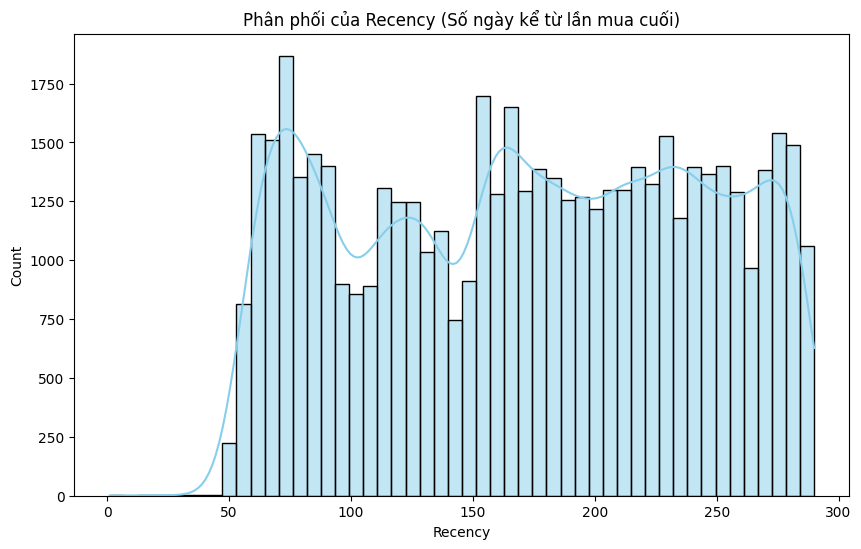

In [24]:
#FILTER DATA FOR R ANALYSIS
master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'])
latest_time = master_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1) #choose the latest figures recorded in the dataset then plus 1 in order not to obtain 0 values

R_df = master_df[master_df['order_purchase_timestamp'].dt.year > 2017] #select the figures recorded after 2017
R_analysis_df = R_df.groupby('customer_unique_id').agg({'order_purchase_timestamp': lambda x: (latest_time-x.max()).days}).reset_index()
R_analysis_df.rename(columns={'order_purchase_timestamp':'Recency'}, inplace=True)
R_analysis_df

plt.figure(figsize=(10, 6))
sns.histplot(R_analysis_df['Recency'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối của Recency (Số ngày kể từ lần mua cuối)')
plt.show()